### **Objective**

---
*The goal of this assignment is to design, implement, and evaluate a Recurrent Neural Network
(RNN) model (using SimpleRNN) to forecast the next day’s temperature based on past weather
data.*

**IMPORTING DATASET**

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muthuj7/weather-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weather-dataset' dataset.
Path to dataset files: /kaggle/input/weather-dataset


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [6]:
print(os.listdir(path))

['weatherHistory.csv']


In [7]:
df=pd.read_csv(os.path.join(path,'weatherHistory.csv'))
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [8]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [10]:
df["Formatted Date"] = pd.to_datetime(df["Formatted Date"], utc=True)

In [11]:
df.head(10)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 03:00:00+00:00,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 04:00:00+00:00,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 05:00:00+00:00,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 06:00:00+00:00,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 07:00:00+00:00,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


# **2)Plot temperature trends over time.**


---

## ***Map Temprature v/s Time***

---



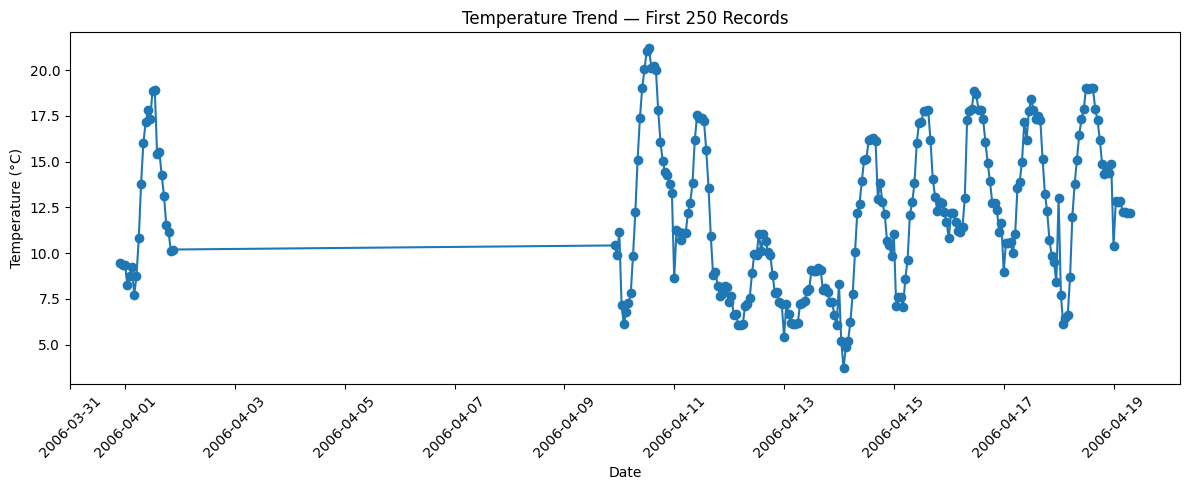

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Formatted Date"].iloc[:250],
    df["Temperature (C)"].iloc[:250],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Trend — First 250 Records")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

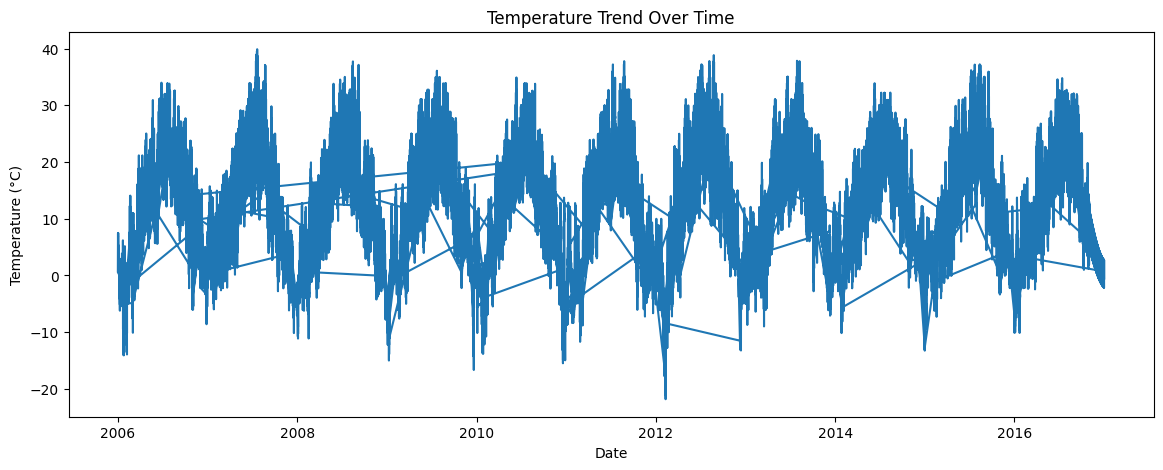

In [13]:
plt.figure(figsize=(14, 5))

plt.plot(df["Formatted Date"], df["Temperature (C)"])

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Trend Over Time")

plt.show()

# **3)Check for missing values.**

---



In [14]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


# **PRE-PREOCESSING STEPS**

---



# **Handle missing values (impute/remove).**

---



In [15]:
fet = [
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)"
]

data = df[fet].copy()
data

,Temperature (C),Humidity,Wind Speed (km/h)
0,9.472222,0.89,14.1197
1,9.355556,0.86,14.2646
2,9.377778,0.89,3.9284
3,8.288889,0.83,14.1036
4,8.755556,0.83,11.0446
...,...,...,...
96448,26.016667,0.43,10.9963
96449,24.583333,0.48,10.0947
96450,22.038889,0.56,8.9838
96451,21.522222,0.60,10.5294


In [16]:
data.isnull().sum()

,0
Temperature (C),0
Humidity,0
Wind Speed (km/h),0


# **NORMALIZATION**

---



In [17]:
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
X=df[features]
y=df['Temperature (C)']
scaler=MinMaxScaler()
y_scaler=MinMaxScaler()
X=scaler.fit_transform(X)
y=y_scaler.fit_transform(y.values.reshape(-1,1))

# **Create input sequences:**

---
■ Use past 7–14 days’ weather data (temperature, humidity, wind speed)
as input.

■ Target: next day’s temperature.

**Setting the number of previous days**

In [18]:
time_steps=14

**Create sequences**

In [19]:
X_seq=[]
y_seq=[]
for i in range(time_steps,len(X)):
  X_seq.append(X[i-time_steps:i])
  y_seq.append(y[i])
X_seq=np.array(X_seq)
y_seq=np.array(y_seq)

In [20]:
print(X_seq)
print(y_seq)

[[[0.50697507 0.89       0.2211296  0.97013513]
  [0.50508505 0.86       0.22339889 0.97061297]
  [0.50544505 0.89       0.06152295 0.97090923]
  ...
  [0.63126631 0.54       0.30988401 0.97262945]
  [0.64188642 0.55       0.34367121 0.97248609]
  [0.63432634 0.51       0.32400403 0.97238097]]

 [[0.50508505 0.86       0.22339889 0.97061297]
  [0.50544505 0.89       0.06152295 0.97090923]
  [0.48780488 0.83       0.22087746 0.9713584 ]
  ...
  [0.64188642 0.55       0.34367121 0.97248609]
  [0.63432634 0.51       0.32400403 0.97238097]
  [0.65934659 0.47       0.24079677 0.97208471]]

 [[0.50544505 0.89       0.06152295 0.97090923]
  [0.48780488 0.83       0.22087746 0.9713584 ]
  [0.49536495 0.83       0.17297025 0.97145397]
  ...
  [0.63432634 0.51       0.32400403 0.97238097]
  [0.65934659 0.47       0.24079677 0.97208471]
  [0.6598866  0.46       0.16288452 0.97141574]]

 ...

 [[0.61389614 0.88       0.04362078 0.97024981]
  [0.6704167  0.75       0.05824508 0.97027848]
  [0.71217

In [21]:
print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

X shape: (96439, 14, 4)
y shape: (96439, 1)


# **Train / Validation / Test split**

---
**Split dataset into train, validation, and test sets.**

In [22]:
train=int(0.70*len(X_seq))
val=int(0.15*len(X_seq))
X_train=X_seq[:train]
y_train=y_seq[:train]
X_val=X_seq[train:train+val]
y_val=y_seq[train:train+val]
X_test=X_seq[train+val:]
y_test=y_seq[train+val:]

0.70 indicates 70% of data for training 0.15 means 15% data for validation and the rest 15% data for testing . [:train] means from start to last of training data ,[train:train+val] means where the training data end is the starting for X_val to last of val_data that is [train+val],similarly [train+val:] means the last of val data to the very last of test data.

In [23]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (67507, 14, 4)
y_train: (67507, 1)
X_val: (14465, 14, 4)
y_val: (14465, 1)
X_test: (14467, 14, 4)
y_test: (14467, 1)


# **RNN Model Development**

---
Build a SimpleRNN model using TensorFlow/Keras:

○ Input layer (with shape = sequence length × number of features).

○ SimpleRNN layer (e.g., 32–64 units).

○ Dropout layer (optional, to avoid overfitting).

○ Dense layer with 1 unit (linear activation for regression).

In [25]:
from tensorflow.keras.layers import SimpleRNN,Dense,Dropout
from tensorflow.keras.models import Sequential

# **RNN MODEL**

---


In [31]:
model = Sequential([SimpleRNN(55, activation='tanh', input_shape=(14, 4)),Dropout(0.2),Dense(1,activation='linear')])
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 55)             │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 55)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,356 (13.11 KB)

 Trainable params: 3,356 (13.11 KB)

 Non-trainable params: 0 (0.00 B)

# **Compile the model**

---
○ Loss: Mean Squared Error (MSE).

○ Optimizer: Adam.

○ Metrics: Mean Absolute Error (MAE).

In [33]:
model.compile(loss='mse',optimizer='adam',metrics=['mae'])

# Train the model on training data:
---
○ Batch size: 32

○ Epochs: 50–100

○ Use validation data to monitor performance.

○ Plot training vs validation loss curves.

In [34]:
history=model.fit(X_train,y_train,batch_size=32,epochs=100,validation_data=(X_val,y_val))

Epoch 1/100
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0040 - mae: 0.0447 - val_loss: 5.0334e-04 - val_mae: 0.0158
Epoch 2/100
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0014 - mae: 0.0275 - val_loss: 4.7362e-04 - val_mae: 0.0153
Epoch 3/100
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 9.9512e-04 - mae: 0.0230 - val_loss: 4.2805e-04 - val_mae: 0.0141
Epoch 4/100
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 8.5808e-04 - mae: 0.0211 - val_loss: 4.7860e-04 - val_mae: 0.0158
Epoch 5/100
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 7.9999e-04 - mae: 0.0202 - val_loss: 3.9611e-04 - val_mae: 0.0136
Epoch 6/100
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 7.8144e-04 - mae: 0.0198 - val_loss: 5.1731e-04 - val_mae: 0.0171
Epoch 7/100
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 7.5988e-04 - mae: 0.0195 - val_loss: 4.3379e-04 - val_mae: 0.0144
Epoch 8/100
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 7.5610e-04 - mae: 0.0194 - val_loss

# **Plot training vs validation loss**

---

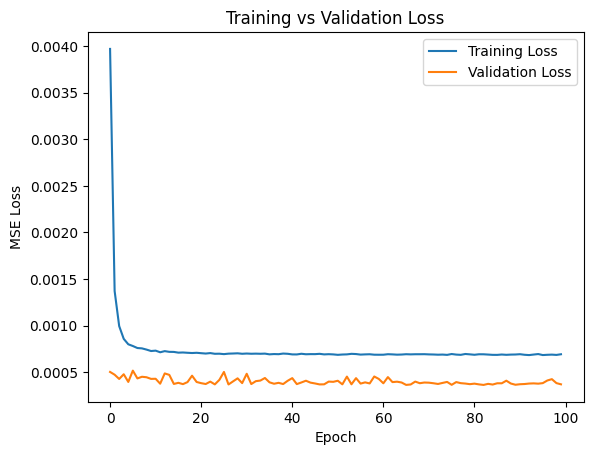

In [35]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# **Model Evaluation & Forecasting**

---
Evaluate the model on the test set:

○ Calculate RMSE, MAE, and R2 score.

○ Plot predicted vs actual temperatures for the test period.


In [36]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.3931e-04 - mae: 0.0124
Test MSE: 0.00033930878271348774
Test MAE: 0.012443450279533863


In [37]:
y_pred = model.predict(X_test)
y_test_actual = y_scaler.inverse_transform(y_test)
y_pred_actual = y_scaler.inverse_transform(y_pred)
print("Actual temperatures:", y_test_actual[:10].flatten())
print("Predicted temperatures:", y_pred_actual[:10].flatten())

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Actual temperatures: [2.06666667 2.61666667 2.57777778 2.68888889 4.77222222 5.96666667
 7.13333333 7.78333333 8.         7.97777778]
Predicted temperatures: [2.5102017 2.3680258 2.8250878 2.8557415 2.8621564 5.1031413 6.472079
 7.6012135 8.17933   8.367856 ]


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE:", mae, "°C")
print("RMSE:", rmse, "°C")
print("R² Score:", r2)

MAE: 0.7681067033660025 °C
RMSE: 1.1370461629771105 °C
R² Score: 0.9838122189295555


# **Plot predicted vs actual temperatures**

---



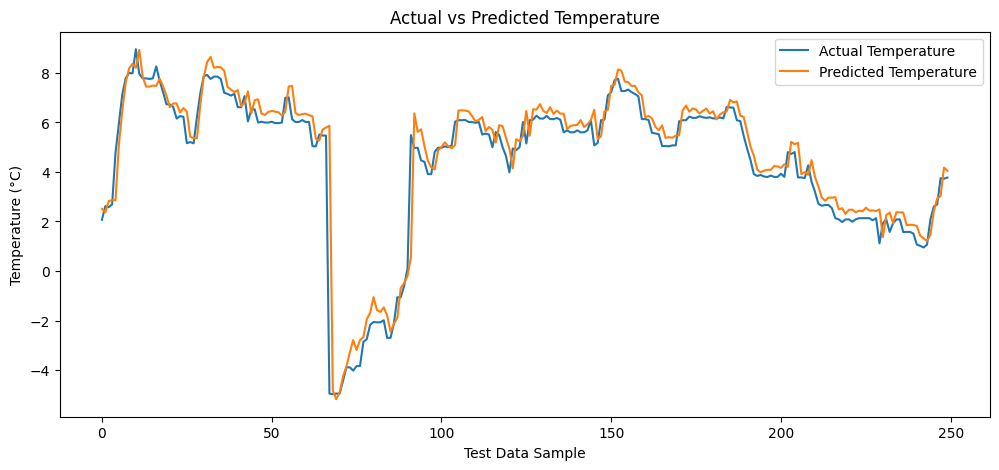

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual[:250],
    label='Actual Temperature'
)

plt.plot(
    y_pred_actual[:250],
    label='Predicted Temperature'
)

plt.xlabel('Test Data Sample')
plt.ylabel('Temperature (°C)')
plt.title('Actual vs Predicted Temperature')
plt.legend()

plt.show()

In [44]:
last_sequence = X_test[-1].copy()

future_predictions = []

for i in range(7):

    # Reshape for the RNN: (1 sample, 14 days, 4 features)
    input_sequence = last_sequence.reshape(1, 14, 4)

    # Predict the next day's temperature
    next_temp_scaled = model.predict(input_sequence, verbose=0)[0, 0]

    # Convert predicted temperature back to °C
    next_temp = y_scaler.inverse_transform(np.array([[next_temp_scaled]]))[0, 0]
    future_predictions.append(next_temp)

    # Create the next day's input
    next_day = last_sequence[-1].copy()

    # Update temperature with the prediction
    next_day[0] = next_temp_scaled

    # Keep the other features unchanged
    last_sequence = np.vstack([
        last_sequence[1:],
        next_day
    ])

print("Next 7 days predicted temperatures:")
for i, temp in enumerate(future_predictions, 1):
    print(f"Day {i}: {temp:.2f} °C")

Next 7 days predicted temperatures:
Day 1: 19.82 °C
Day 2: 18.28 °C
Day 3: 16.98 °C
Day 4: 15.84 °C
Day 5: 14.92 °C
Day 6: 14.28 °C
Day 7: 14.02 °C


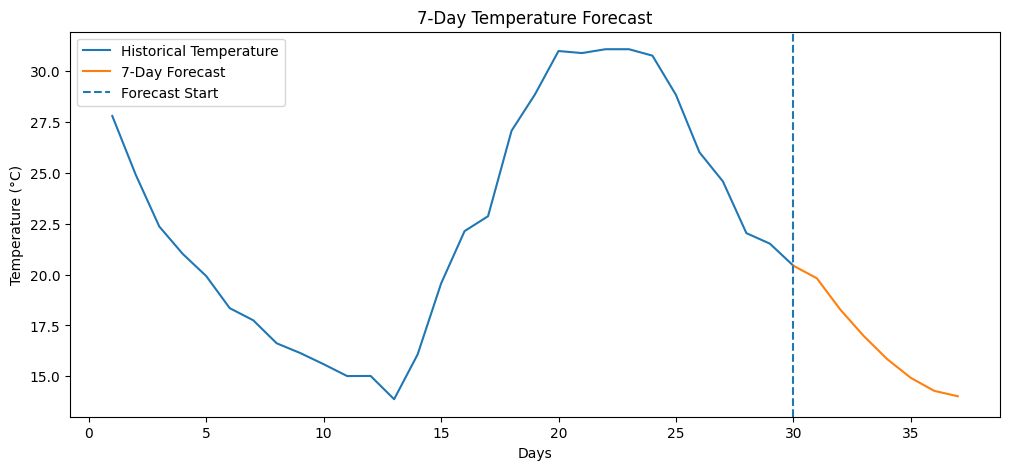

In [45]:
# Get recent historical temperatures
recent_actual = y_test_actual[-30:].flatten()

# Combine historical and future values
all_temperatures = np.concatenate([
    recent_actual,
    future_predictions
])

plt.figure(figsize=(12, 5))

plt.plot(
    range(1, len(recent_actual) + 1),
    recent_actual,
    label='Historical Temperature'
)

plt.plot(
    range(len(recent_actual), len(all_temperatures) + 1),
    all_temperatures[len(recent_actual)-1:],
    label='7-Day Forecast'
)

plt.axvline(
    x=len(recent_actual),
    linestyle='--',
    label='Forecast Start'
)

plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.title('7-Day Temperature Forecast')
plt.legend()

plt.show()